In [ ]:
from pdf2image import convert_from_path
import matplotlib.pyplot as plt
from byaldi import RAGMultiModalModel
import os

In [ ]:
INSERT_PATH = os.environ('path_to_somewhere', None)

In [ ]:
path = INSERT_PATH

In [13]:
image = convert_from_path(path, dpi=300, poppler_path=r'C:\Program Files (x86)\poppler-26.02.0\Library\bin')

In [ ]:
fig, axes = plt.subplots(1, 8, figsize=(15, 10))

for i, ax in enumerate(axes.flat):
    img = image[i]
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [20]:
os.makedirs('./images', exist_ok=True)

In [22]:
for i, im in enumerate(image):
    im.save(f'./images/{i}_image.png')

In [3]:
docs_retrieval_model = RAGMultiModalModel.from_pretrained("vidore/colpali-v1.2")

Verbosity is set to 1 (active). Pass verbose=0 to make quieter.


Loading weights: 100%|██████████| 2/2 [00:00<00:00,  4.64it/s]
[transformers] ColPali LOAD REPORT from: vidore/colpali-v1.2
Key                                                                               | Status     | 
----------------------------------------------------------------------------------+------------+-
model.language_model.model.layers.{0...17}.self_attn.k_proj.lora_B.default.weight | UNEXPECTED | 
model.language_model.model.layers.{0...17}.self_attn.k_proj.lora_A.default.weight | UNEXPECTED | 
model.language_model.model.layers.{0...17}.self_attn.v_proj.lora_B.default.weight | UNEXPECTED | 
model.language_model.model.layers.{0...17}.self_attn.v_proj.lora_A.default.weight | UNEXPECTED | 
model.language_model.model.layers.{0...17}.self_attn.q_proj.lora_B.default.weight | UNEXPECTED | 
model.language_model.model.layers.{0...17}.mlp.gate_proj.lora_B.default.weight    | UNEXPECTED | 
model.language_model.model.layers.{0...17}.mlp.gate_proj.lora_A.default.weight    | UNEXPECT

In [ ]:
docs_retrieval_model.index(
    input_path="./images/",
    index_name='image_index',
    store_collection_with_index=False,
    overwrite=True
)

Quick conclusions:

This is in no way plausibel in a small size company setting. The point is to introduce local llm models as agentic assistants for construction projects, and that limits the use of large models and too time consuming interaction. The expected indexing time would have been ~90min, which granted would be viable in case:

- agentic assistant downloads tendering material from email and pre-parses documentation
- does preliminary all indexing and vectorization

this might actually be an ideal workflow that has been in discussion: the local model serves as a triage agent that assigns the cost estimations and does preliminary tasks, such as pre-parses tendering material, assigns the project to a project manager, sends or suggests preliminary requests for offers etc. But as such the workflow needs revisioning.

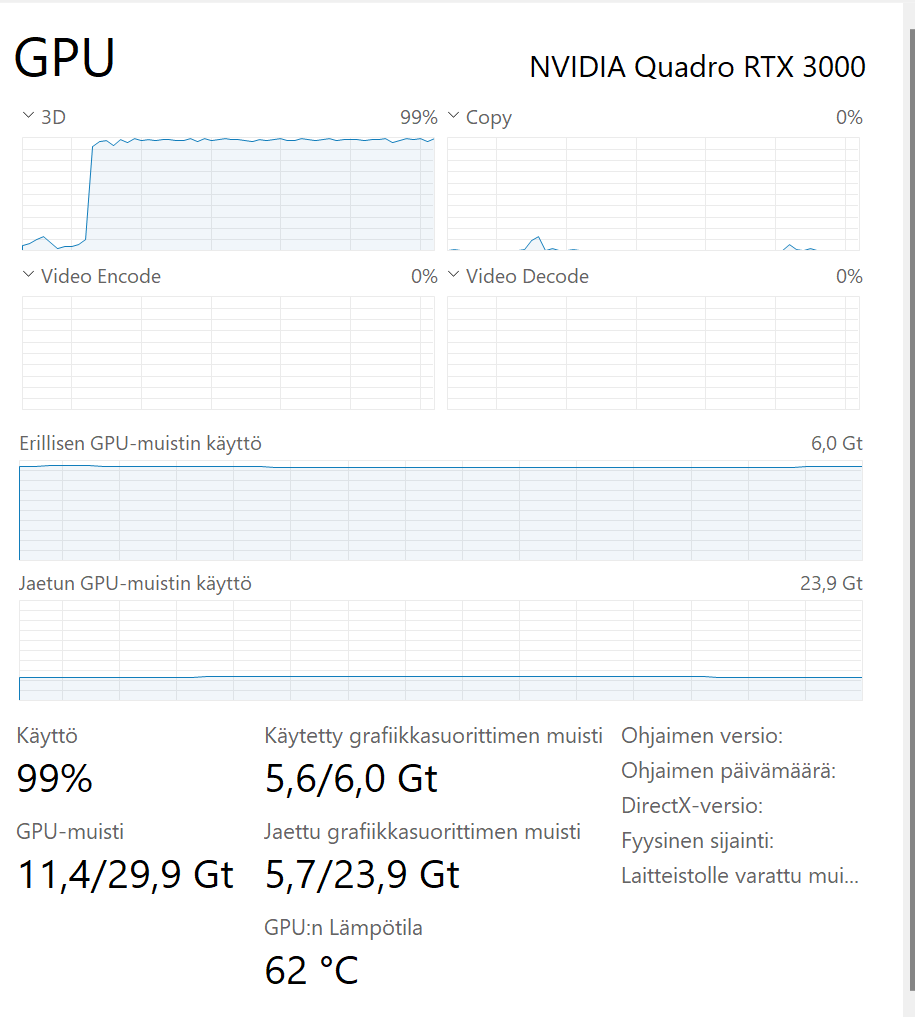